# <u>Submission instructions</u>
### Submission in pairs unless otherwise authorized
<ul style="font-size: 17px">
<li> This notebook contains all the questions. You should follow the instructions below.</li>
<li> Solutions for both theoretical and practical parts should be provided in this notebook</li>
</ul>

<h3> Moodle submission</h3>


<p style="font-size: 17px">
You should submit three files:
</p>
<ul style="font-size: 17px">
<li>IPYNB notebook:
  <ul>
  <li>All the wet and dry parts, including code, graphs, discussion, etc.</li>
  </ul>
</li>
<li>PDF file:
  <ul>
  <li>Export the notebook to PDF. Make sure that all the cells are visible.</li>
  </ul>
</li>
<li>Pickle files:
  <ul>
    <li>As requested in Q3.2.a and Q4.a</li>
  </ul>
</li>
</ul>
<p style="font-size: 17px">
All files should be in the following format: "HW1_ID1_ID2.file"
<br>
Good Luck!
</p>


# Question 1 (15pt)


We mentioned in the lecture and tutorial that neural networks, thanks to their non-linear activation functions, can express a much wider range of functions than just linear ones.

In each of the following exercises, you are given the weight matrices, biases and activations of a small neural network. Express the network's output as a simplified, well-known mathematical function and provide a short explanation. There is no need to prove correctness, an intuitive explanation is enough.

The activation function (non-linearity) is denoted as $g$. The output is given by:

$$s = W_2 g(W_1 x + b_1) + b_2.$$

In network 4, we also apply the activation to the final output, meaning the network's output is $g(s)$. When not stated otherwise, the bias vector is 0.


### Network 1

$$x \in \mathbb{R}. \quad W_1=\begin{pmatrix} 1 \\ -1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1\end{pmatrix}. \quad g=\text{ReLU}.$$

Given:
* x ∈ ℝ
* W₁ = [1, -1]
* W₂ = [1, 1]
* Activation: g = ReLU
* Biases: b₁ = 0, b₂ = 0

### Step 1: Hidden layer pre-activation
z = W₁x + b₁ = [1, -1]x = [x, -x]

### Step 2: Apply ReLU
h = g(z) = [ReLU(x), ReLU(-x)]

Recall:
* If x ≥ 0: ReLU(x) = x, ReLU(-x) = 0
* If x < 0: ReLU(x) = 0, ReLU(-x) = -x

### Step 3: Output
s = W₂h + b₂ = [1, 1][ReLU(x), ReLU(-x)] = ReLU(x) + ReLU(-x)

### Step 4: Piecewise simplification
Case 1: x ≥ 0
s = x + 0 = x

Case 2: x < 0
s = 0 + (-x) = -x

### Final function
s = |x|

### Explanation
The network computes the absolute value of the input.
One neuron receives x, and the other receives -x.
ReLU keeps only the positive part of each input.
Their sum yields the magnitude of the input: ReLU(x) + ReLU(-x) = |x|
The network is therefore a piecewise linear representation of the absolute value, not a linear one.

### Network 2

$$x \in \mathbb{R}^2. \quad W_1 = \begin{pmatrix}-1 & 1 \\ 1 & 0 \\ -1 & 0\end{pmatrix}, W_2 = \begin{pmatrix}1 & 1 & -1\end{pmatrix}. \quad g=\text{ReLU}.$$

s(x1,x2)=max(x1,x2)

Intuitive Explanation
This network effectively compares the two inputs (x_1) and (x_2).

Two of the hidden neurons split (x_1) into its positive and negative parts.
When the output layer subtracts these two parts, it reconstructs the original value (x_1).
So the network’s output always starts from (x_1).

The remaining hidden neuron checks whether (x_2) is larger than (x_1).
It outputs a positive value only when (x_2 > x_1), and the size of that positive value is exactly how much (x_2) exceeds (x_1).
If (x_2 = x_1), it contributes nothing.

By adding this “extra amount” to (x_1), the network ends up selecting whichever of the two numbers is bigger.
If (x_1) is larger, nothing is added.
If (x_2) is larger, the network adds exactly enough to reach (x_2).

Therefore, the final output of the network is simply:

[ max(x_1, x_2). ]

### Network 3

$$x=\begin{pmatrix}x_1 \\ x_2 \\ y_1 \\ y_2\end{pmatrix} \in \mathbb{R}^4. \quad W_1 = \begin{pmatrix} 1 & 0 & -1 & 0 \\ -1 & 0 & 1 & 0 \\ 0 & 1 & 0 & -1 \\ 0 & -1 & 0 & 1\end{pmatrix}, W_2 = \begin{pmatrix} 1 & 1 & 1 & 1 \end{pmatrix}. \quad g = \text{ReLU}.$$

Given:
* x ∈ R⁴
* x = (x₁, x₂, x₃, x₄)
* W₁ =
  [
    [ 1,  0, -1,  0],
    [-1,  0,  1,  0],
    [ 0,  1,  0, -1],
    [ 0, -1,  0,  1]
  ]
* W₂ = [1, 1, 1, 1]
* Activation: g = ReLU
* Biases: b₁ = 0, b₂ = 0


### Step 1: Hidden layer pre-activation
z = W₁ x =

[
  x₁ - x₃,
 -x₁ + x₃,
  x₂ - x₄,
 -x₂ + x₄
]


### Step 2: Apply ReLU
h = g(z) =
[
  ReLU(x₁ - x₃),
  ReLU(-x₁ + x₃),
  ReLU(x₂ - x₄),
  ReLU(-x₂ + x₄)
]


### Step 3: Output
s = W₂ h + b₂  
  = ReLU(x₁ - x₃)
  + ReLU(x₃ - x₁)
  + ReLU(x₂ - x₄)
  + ReLU(x₄ - x₂)


### Step 4: Piecewise simplification

Recall the identity:
ReLU(a) + ReLU(-a) = |a|

So:

ReLU(x₁ - x₃) + ReLU(x₃ - x₁) = |x₁ - x₃|  
ReLU(x₂ - x₄) + ReLU(x₄ - x₂) = |x₂ - x₄|

Thus:

s = |x₁ - x₃| + |x₂ - x₄|


### Final function
s = |x₁ - x₃| + |x₂ - x₄|


### Explanation
The network computes the L₁ distance (Manhattan distance) between two 2D points:

Point A: (x₁, x₂)  
Point B: (x₃, x₄)

Each pair of coordinates is processed through two ReLU neurons:
* ReLU(xᵢ - xⱼ)
* ReLU(xⱼ - xᵢ)

Their sum equals the absolute value of the difference |xᵢ - xⱼ|.

Summing both coordinate differences gives:

|x₁ - x₃| + |x₂ - x₄|

This is a piecewise linear representation of the Manhattan distance, not a linear one, formed using ReLU activations.


### Network 4

Here, the non-linearity is applied also to the output of the second layer. For simplicity, assume $ \forall x \ge 10, \text{sigmoid}(x) = 1, \text{sigmoid}(-x) = 0$.

$$x \in \{0, 1\}^2 \quad \text{(binary vector)}.$$

$$W_1 = \begin{pmatrix} 20 & 20 \\ -20 & -20 \end{pmatrix}, b_1 = \begin{pmatrix} -10 \\ 30 \end{pmatrix}, W_2 = \begin{pmatrix} 20 & 20 \end{pmatrix}, b_2 = -30. \quad g=\text{sigmoid}.$$

s=XOR(x1,x2)


 Intuitive Explanation The input to the network is a binary vector, meaning each input is either 0 or 1. Because the weights in the network are very large (20 and –20), the values entering each sigmoid neuron become very large positive or very large negative numbers. With the given assumption that sigmoid(x) ≈ 1 for x ≥ 10 and sigmoid(x) ≈ 0 for x ≤ –10, each neuron behaves like a simple "on/off" switch.

In the first layer, the network produces two logical signals:

One hidden neuron turns on whenever at least one of the inputs is 1. This behaves like the logical OR.

The other hidden neuron turns on whenever the two inputs are not both 1. This behaves like the logical NAND.

The second layer combines these two hidden outputs. It turns on only when both hidden neurons are on at the same time. This condition is true exactly when one input is 1 and the other is 0.

Why? Because in that situation both conditions are satisfied simultaneously:

OR = 1 (at least one input is 1)

NAND = 1 (the inputs are not both 1)

In all other cases—when both inputs are 0 or both inputs are 1—at least one of these conditions fails, so the output is 0.

Therefore, the network outputs 1 only when the two inputs are different, which is exactly the behavior of the XOR function.


# Question 2

We recommend checking the hidden slides in tutorial 1 before approaching these exercises.

## I. Softmax Derivative (5pt)

Derive the gradients of the softmax function and demonstrate how the expression can be reformulated solely by using the softmax function, i.e., in some expression where only $\text{softmax}(x)$, but not $x$, is present. Recall that the softmax function is defined as follows:

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}}$$

### I. Softmax Derivative - Answer:
$$
\frac{\partial\,\mathrm{softmax}(x)_i}{\partial x_k}
=
\mathrm{softmax}(x)i \left( \delta{ik} - \mathrm{softmax}(x)_k \right)
$$

## II. Cross-Entropy Gradient (5pt)

Derive the gradient of cross-entropy loss with regard to the inputs of a softmax function. i.e., find the gradients with respect to the softmax input vector $\theta$, when the prediction is denoted by $\hat{y} = \text{softmax}(\theta)$. Remember the cross entropy function is:
$$CE(y, \hat{y}) = -\sum_i y_i log(\hat{y_i})$$


where $y$ is the one-hot label vector, and $\hat{y}$ is the predicted probability vector for all classes.

### II. Cross-Entropy Gradient - Answer

<!--- write your answer -->
$$\frac{\partial CE(y, \hat{y})}{\partial\theta} = \text{Go for it}$$

## Cross-Entropy Gradient Derivation

 We are given a softmax classifier with logits vector  
 θ ∈ ℝᴷ and prediction:

 ŷᵢ = softmax(θᵢ) = e^(θᵢ) / ∑ₖ₌₁ᴷ e^(θₖ)

 The cross-entropy loss is:

 CE(y, ŷ) = - ∑ᵢ₌₁ᴷ yᵢ log(ŷᵢ)



 Step 1: Derivative w.r.t. softmax outputs

 ∂CE/∂ŷᵢ = -yᵢ/ŷᵢ

 Step 2: Derivative of softmax w.r.t logits

 ∂ŷᵢ/∂θⱼ = ŷᵢ(δᵢⱼ - ŷⱼ)

 Step 3: Chain rule

 ∂CE/∂θⱼ = ∑ᵢ₌₁ᴷ (∂CE/∂ŷᵢ) · (∂ŷᵢ/∂θⱼ)

 Substitute:

 = ∑ᵢ₌₁ᴷ (-yᵢ/ŷᵢ) · ŷᵢ(δᵢⱼ - ŷⱼ)

 Simplify:

 = -∑ᵢ yᵢδᵢⱼ + ŷⱼ∑ᵢ yᵢ

 Using one-hot vector properties:

 ∑ᵢ yᵢδᵢⱼ = yⱼ
 ∑ᵢ yᵢ = 1

 Final gradient:

 ∂CE/∂θⱼ = ŷⱼ - yⱼ

 Vector form:

 ∇θ CE = ŷ - y

# Question 3

## I. Derivative Of Activation Functions (5pt)

The following cell contains an implementation of some activation functions. Implement the corresponding derivatives.

In [3]:
import torch

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    return torch.div(torch.exp(x) - torch.exp(-x), torch.exp(x) + torch.exp(-x))


def softmax(x):
    exp_x = torch.exp(x.T - torch.max(x, dim=-1).values).T  # Subtracting max(x) for numerical stability
    return exp_x / exp_x.sum(dim=-1, keepdim=True)

In [4]:
def d_sigmoid(x):
    """
    Derivative of the sigmoid activation.
    σ(x) = 1 / (1 + e^{-x})
    σ'(x) = σ(x) * (1 - σ(x))
    """
    s = sigmoid(x)
    return s * (1.0 - s)


def d_tanh(x):
    """
    Derivative of the tanh activation.
    tanh'(x) = 1 - tanh(x)^2
    """
    t = tanh(x)
    return 1.0 - t**2


def d_softmax(x):
    s = softmax(x)                     # (B, C)
    diag_s = torch.diag_embed(s)       # (B, C, C)
    outer = s.unsqueeze(2) * s.unsqueeze(1)  # (B, C, C)
    return diag_s - outer


## II. Train a Fully Connected network on MNIST (30pt)

In the following exercise, you will create a classifier for the MNIST dataset.
You should write your own training and evaluation code and meet the following
constraints:
<ul>
<li> You are only allowed to use torch tensor manipulations.</li>
<li> You are NOT allowed to use:
  <ul>
  <li> Auto-differentiation - backward()</li>
  <li> Built-in loss functions</li>
  <li> Built-in activations</li>
  <li> Built-in optimization</li>
  <li> Built-in layers (torch.nn)</li>
  </ul>
  </li>
</ul>
</h4>

a. The required classifier class is defined.

You should implement the forward and backward passes of the model.
Train the model and plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
You should save the model's weights and biases. Change the student_ids to yours.

In this section, you <b>must</b> use the "set_seed" function with the given seed and <b>sigmoid</b> as an activation function.

In [5]:
import torch
import torchvision
from torch.utils.data import DataLoader

import os
import matplotlib.pyplot as plt

# Constants
SEED = 42
EPOCHS = 16
BATCH_SIZE = 32
NUM_OF_CLASSES = 10

# Setting seed
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


# Transformation for the data
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torch.flatten])


# Cross-Entropy loss implementation
def one_hot(y, num_of_classes=10):
    hot = torch.zeros((y.size()[0], num_of_classes))
    hot[torch.arange(y.size()[0]), y] = 1
    return hot

def cross_entropy(y, y_hat):
    return -torch.sum(one_hot(y) * torch.log(y_hat)) / y.size()[0]

In [7]:
# Create dataloaders
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE)


test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                           download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,)

In [8]:
class FullyConnectedNetwork:
    def __init__(self, input_size, output_size, hidden_size1, activiation_func, lr=0.01):
        # parameters
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size1 = hidden_size1

        # activation function
        self.activation_func = activiation_func

        # weights
        self.W1 = torch.randn(self.input_size, self.hidden_size1)
        self.b1 = torch.zeros(self.hidden_size1)

        self.W2 = torch.randn(self.hidden_size1, self.output_size)
        self.b2 = torch.zeros(self.output_size)

        self.lr = lr

    def forward(self, x):
        # 1) reshape image to (batch_size, 784)
        x = x.view(x.size(0), -1)

        # 2) linear layer 1
        z1 = x @ self.W1 + self.b1

        # 3) activation
        h1 = self.activation_func(z1)

        # 4) linear layer 2
        z2 = h1 @ self.W2 + self.b2

        # 5) softmax
        y_hat = self.stable_softmax(z2)

        return y_hat

    def stable_softmax(self, z):
        z_shifted = z - z.max(dim=1, keepdim=True).values
        exp_scores = torch.exp(z_shifted)
        return exp_scores / torch.sum(exp_scores, dim=1, keepdim=True)

    def backward(self, x, y, y_hat):
        batch_size = x.size(0)

        # reshape as in forward
        x = x.view(batch_size, -1)

        # forward pass values (recomputed)
        z1 = x @ self.W1 + self.b1
        h1 = self.activation_func(z1)

        # one-hot labels
        y_one_hot = one_hot(y, num_of_classes=self.output_size)

        # derivative of softmax + cross-entropy
        dz2 = (y_hat - y_one_hot) / batch_size

        # gradients second layer
        dW2 = h1.t() @ dz2
        db2 = dz2.sum(dim=0)

        # backprop to hidden layer
        dh1 = dz2 @ self.W2.t()
        dz1 = dh1 * h1 * (1 - h1)

        # gradients first layer
        dW1 = x.t() @ dz1
        db1 = dz1.sum(dim=0)

        # update weights
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

In [9]:
set_seed(SEED)
model = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=0.01)

Epoch 1/16 | Train loss: 0.3343, Train acc: 0.9021 | Test loss: 0.3483, Test acc: 0.8972
Epoch 2/16 | Train loss: 0.3298, Train acc: 0.9034 | Test loss: 0.3447, Test acc: 0.8984
Epoch 3/16 | Train loss: 0.3256, Train acc: 0.9046 | Test loss: 0.3413, Test acc: 0.8990
Epoch 4/16 | Train loss: 0.3215, Train acc: 0.9059 | Test loss: 0.3380, Test acc: 0.8998
Epoch 5/16 | Train loss: 0.3176, Train acc: 0.9070 | Test loss: 0.3348, Test acc: 0.9003
Epoch 6/16 | Train loss: 0.3138, Train acc: 0.9078 | Test loss: 0.3317, Test acc: 0.9018
Epoch 7/16 | Train loss: 0.3101, Train acc: 0.9085 | Test loss: 0.3288, Test acc: 0.9029
Epoch 8/16 | Train loss: 0.3066, Train acc: 0.9094 | Test loss: 0.3259, Test acc: 0.9038
Epoch 9/16 | Train loss: 0.3033, Train acc: 0.9104 | Test loss: 0.3232, Test acc: 0.9047
Epoch 10/16 | Train loss: 0.3000, Train acc: 0.9113 | Test loss: 0.3206, Test acc: 0.9052
Epoch 11/16 | Train loss: 0.2969, Train acc: 0.9122 | Test loss: 0.3180, Test acc: 0.9059
Epoch 12/16 | Train

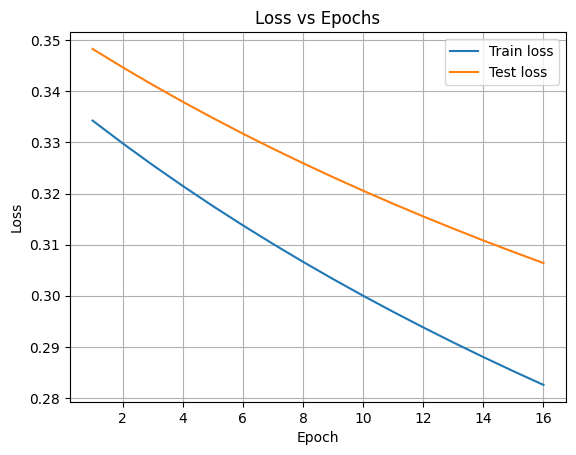

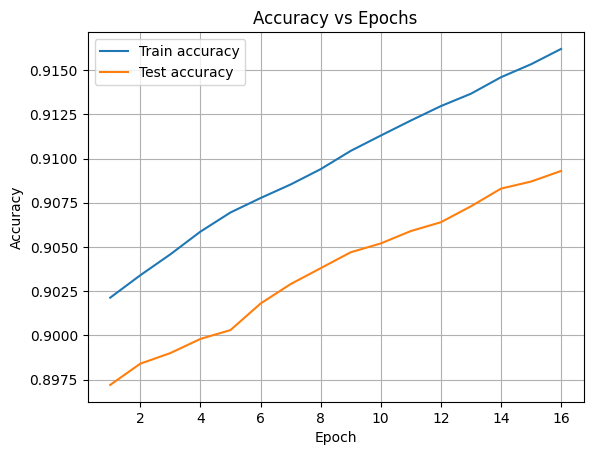

In [13]:
# רשימות לשמירת ההפסד והדיוק לאורך האפוקים
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(EPOCHS):
    # ----- אימון על train -----
    total_train_loss = 0.0
    total_train_correct = 0
    total_train_samples = 0

    for x_batch, y_batch in train_dataloader:
        # 1) מעבר קדימה - חיזוי y_hat
        y_hat = model.forward(x_batch)          # shape: [batch_size, 10]

        # 2) חישוב ההפסד לבאץ'
        loss = cross_entropy(y_batch, y_hat)    # scalar

        # 3) צבירת ההפסד (לממוצע בסוף)
        batch_size_current = x_batch.size(0)
        total_train_loss += loss.item() * batch_size_current

        # 4) חישוב דיוק על הבאץ' (argmax על ההסתברויות)
        preds = torch.argmax(y_hat, dim=1)      # מחזיר את המספר החזוי 0–9
        total_train_correct += (preds == y_batch).sum().item()
        total_train_samples += batch_size_current

        # 5) מעבר אחורה + עדכון משקולות
        model.backward(x_batch, y_batch, y_hat)

    # ממוצע הפסד ודיוק על כל ה-train
    avg_train_loss = total_train_loss / total_train_samples
    train_acc = total_train_correct / total_train_samples

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ----- הערכה על test -----
    total_test_loss = 0.0
    total_test_correct = 0
    total_test_samples = 0

    # כאן לא מעדכנים משקולות, רק מודדים ביצועים
    for x_batch, y_batch in test_dataloader:
        y_hat = model.forward(x_batch)
        loss = cross_entropy(y_batch, y_hat)

        batch_size_current = x_batch.size(0)
        total_test_loss += loss.item() * batch_size_current

        preds = torch.argmax(y_hat, dim=1)
        total_test_correct += (preds == y_batch).sum().item()
        total_test_samples += batch_size_current

    avg_test_loss = total_test_loss / total_test_samples
    test_acc = total_test_correct / total_test_samples

    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, Train acc: {train_acc:.4f} | "
          f"Test loss: {avg_test_loss:.4f}, Test acc: {test_acc:.4f}")

# ===== אחרי הלולאה: ציור הגרפים =====
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# גרף הפסד
plt.figure()
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

# גרף דיוק
plt.figure()
plt.plot(epochs, train_accuracies, label="Train accuracy")
plt.plot(epochs, test_accuracies, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

torch.save({
    "W1": model.W1,
    "b1": model.b1,
    "W2": model.W2,
    "b2": model.b2
}, "mnist_fc_weights.pt")

In [14]:
students_ids = "325468510_213690928"
torch.save({"W1": model.W1, "W2": model.W2, "b1": model.b1, "b2": model.b2}, f"HW1_{students_ids}.pkl")

b. Train the model with various learning rates (at least 3).

Plot the model's accuracy and loss (both on train and test sets) as a function of the epochs.
Discuss the differences in training with different learning rates. Support your answer with plots.

In [15]:
learning_rates = [0.001, 0.01, 0.1]  # לפחות 3 ערכים
histories = {}  # כדי לשמור את התוצאות לכל lr

for lr in learning_rates:
    print(f"\n========== Training with lr = {lr} ==========")

    # חשוב! לאתחל את הזרע ואת המודל מחדש לכל lr
    set_seed(SEED)
    model = FullyConnectedNetwork(784, 10, 128, sigmoid, lr=lr)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        # ----- אימון על train -----
        total_train_loss = 0.0
        total_train_correct = 0
        total_train_samples = 0

        for x_batch, y_batch in train_dataloader:
            # 1) forward
            y_hat = model.forward(x_batch)

            # 2) loss
            loss = cross_entropy(y_batch, y_hat)

            # 3) צבירת הפסד
            batch_size_current = x_batch.size(0)
            total_train_loss += loss.item() * batch_size_current

            # 4) דיוק
            preds = torch.argmax(y_hat, dim=1)
            total_train_correct += (preds == y_batch).sum().item()
            total_train_samples += batch_size_current

            # 5) backward + עדכון משקולות
            model.backward(x_batch, y_batch, y_hat)

        avg_train_loss = total_train_loss / total_train_samples
        train_acc = total_train_correct / total_train_samples
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # ----- הערכה על test -----
        total_test_loss = 0.0
        total_test_correct = 0
        total_test_samples = 0

        with torch.no_grad():  # לא חייב, אבל טוב
            for x_batch, y_batch in test_dataloader:
                y_hat = model.forward(x_batch)
                loss = cross_entropy(y_batch, y_hat)

                batch_size_current = x_batch.size(0)
                total_test_loss += loss.item() * batch_size_current

                preds = torch.argmax(y_hat, dim=1)
                total_test_correct += (preds == y_batch).sum().item()
                total_test_samples += batch_size_current

        avg_test_loss = total_test_loss / total_test_samples
        test_acc = total_test_correct / total_test_samples
        test_losses.append(avg_test_loss)
        test_accuracies.append(test_acc)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train loss: {avg_train_loss:.4f}, Train acc: {train_acc:.4f} | "
              f"Test loss: {avg_test_loss:.4f}, Test acc: {test_acc:.4f}")

    # לשמור את כל ההיסטוריה של ה-lr הזה
    histories[lr] = {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
}


========== Training with lr = 0.001 ==========
Epoch 1/16 | Train loss: 8.0070, Train acc: 0.1355 | Test loss: 5.9927, Test acc: 0.1709
Epoch 2/16 | Train loss: 5.2537, Train acc: 0.1931 | Test loss: 4.6852, Test acc: 0.2262
Epoch 3/16 | Train loss: 4.3004, Train acc: 0.2521 | Test loss: 3.8949, Test acc: 0.2872
Epoch 4/16 | Train loss: 3.6346, Train acc: 0.3108 | Test loss: 3.3207, Test acc: 0.3497
Epoch 5/16 | Train loss: 3.1449, Train acc: 0.3647 | Test loss: 2.8955, Test acc: 0.3986
Epoch 6/16 | Train loss: 2.7770, Train acc: 0.4114 | Test loss: 2.5726, Test acc: 0.4423
Epoch 7/16 | Train loss: 2.4942, Train acc: 0.4517 | Test loss: 2.3217, Test acc: 0.4763
Epoch 8/16 | Train loss: 2.2722, Train acc: 0.4860 | Test loss: 2.1224, Test acc: 0.5083
Epoch 9/16 | Train loss: 2.0944, Train acc: 0.5161 | Test loss: 1.9611, Test acc: 0.5373
Epoch 10/16 | Train loss: 1.9492, Train acc: 0.5415 | Test loss: 1.8281, Test acc: 0.5622
Epoch 11/16 | Train loss: 1.8287, Train acc: 0.5620 | Test lo

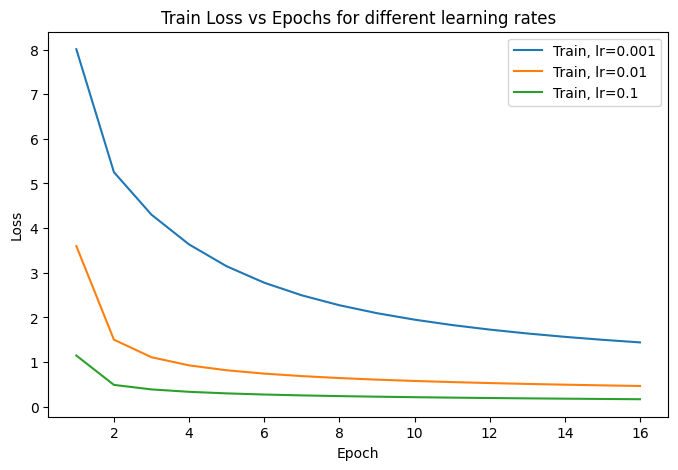

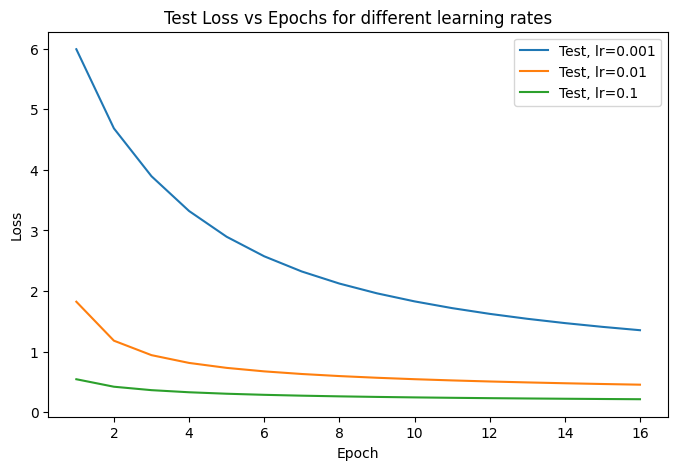

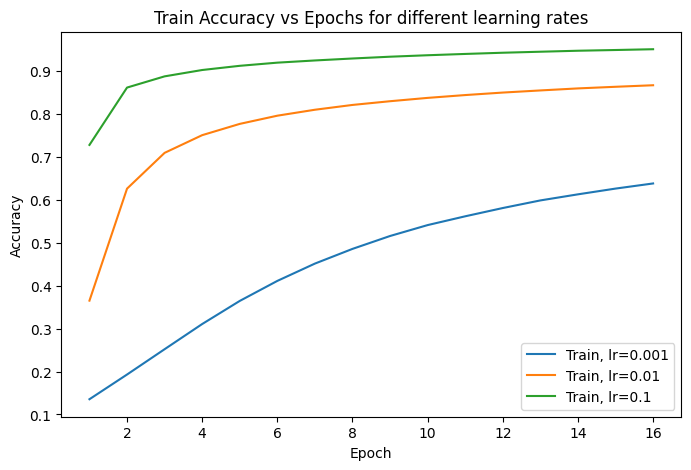

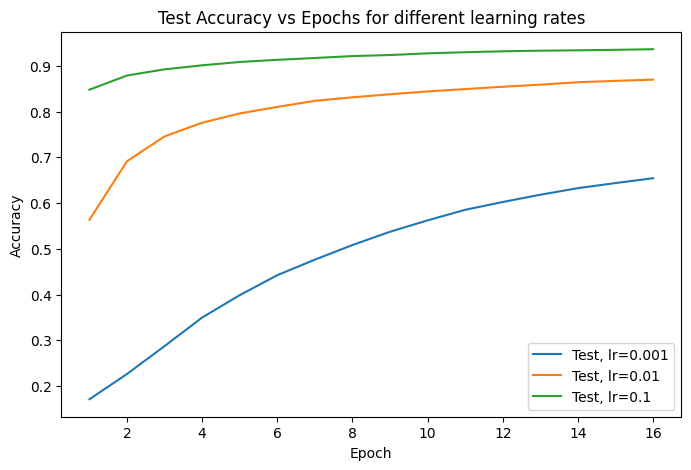

In [17]:
epochs_range = range(1, EPOCHS + 1)

# 1. Train loss
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(epochs_range, histories[lr]["train_losses"], label=f"Train, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss vs Epochs for different learning rates")
plt.legend()
plt.show()

# 2. Test loss
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(epochs_range, histories[lr]["test_losses"], label=f"Test, lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Test Loss vs Epochs for different learning rates")
    plt.legend()
plt.show()

# 3. Train accuracy
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(epochs_range, histories[lr]["train_accuracies"], label=f"Train, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy vs Epochs for different learning rates")
plt.legend()
plt.show()

# 4. Test accuracy
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(epochs_range, histories[lr]["test_accuracies"], label=f"Test, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs Epochs for different learning rates")
plt.legend()
plt.show()

We trained the same fully connected network with three different learning rates: 0.001, 0.01, and 0.1.
For lr = 0.001, both the training and test loss decreased very slowly, and the accuracy improved only from ~13% to about 65% after 16 epochs. This indicates that the learning rate is too small: the updates to the weights are very small, so the model learns in the right direction, but the convergence is very slow and the model remains underfitted within the given number of epochs.

For lr = 0.01, the model converged much faster. The train and test loss dropped steadily, and the train accuracy reached about 86–87%, while the test accuracy reached around 87%. The curves are relatively smooth and stable, which suggests that this learning rate provides a good balance between convergence speed and stability.

For lr = 0.1, the model learned even faster: already in the first few epochs the loss decreased sharply and the accuracy reached over 90%. After 16 epochs, the train accuracy was about 95% and the test accuracy about 93–94%. In our case, the training remained stable and did not diverge, so this higher learning rate gave the best performance among the three.

Overall, we observe that too small a learning rate (0.001) leads to very slow convergence and relatively low final accuracy, while moderate and higher learning rates (0.01 and 0.1) allow the model to converge faster and achieve significantly better performance. In this experiment, lr = 0.1 achieved the highest accuracy on both the training and test sets.

# Question 4

We recommend using GPUs to solve this section. You can use free GPUs provided by Google Colab or by Kaggle (instructions on how to connect are in Moodle). Also, we recommend going over all tutorial notebooks and using dropout, normalization and Adam for better learning. Solving this on your personal computer will be significantly slower than using cloud computation.

## I. Implement and Train a CNN (30pt)

Whenever Ben sees a cat, his first instinct is to run up and pet them. However, after a recent incident he realized not all types of cats are very fond of that type of attention. Train a classifier to tell the difference between different types of big cats, and help Ben from putting himself in too much danger.

Your code should meet the following constraints:

1. Your classifier must be CNN based.
2. You are not allowed to use any pre-trained model.

#### Stages
1. Perform a short EDA (Exploratory Data Analysis).
2. Train the model and plot its accuracy and loss (for both the training and validation sets) as a function of the epochs. Display the overall number of parameters in the model. To see the number of parameters in your model, run `sum(p.numel() for p in model.parameters())`.
3. Report the test set accuracy.

 Your data is in `hw1_data/big_cats`.

You can use the provided code for preprocessing the data. You can also define a custom dataset (as in tutorial 3) or use `torchvision.datasets.ImageFolder` if you prefer. **Your training function must call the `set_seed` command for reproducibility**.

 #### Submission
In addition to the code in the notebook, you should submit:

1. a `.py` file containing your model class.
2. a `.pkl` file containing the weight of your model.

#### Grading
- 5 points for EDA.
- 15 points based on reaching minimum test accuracy (77% accuracy required to get all 15 points, 70% accuracy to get 10 points).
- 10 points competitive: try to balance the tradeoff between number of parameters in your model and model's test accuracy. The lower the # of parameters and the higher the test accuracy, the higher the final score.

Number of training images: 2339
Number of validation images: 50
Number of test images: 50

Classes: ['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']
Number of classes: 10

Train distribution: {'PUMA': 236, 'AFRICAN LEOPARD': 236, 'JAGUAR': 238, 'SNOW LEOPARD': 231, 'CHEETAH': 235, 'CLOUDED LEOPARD': 229, 'CARACAL': 236, 'LIONS': 228, 'OCELOT': 233, 'TIGER': 237}
Validation distribution: {'PUMA': 5, 'AFRICAN LEOPARD': 5, 'JAGUAR': 5, 'SNOW LEOPARD': 5, 'CHEETAH': 5, 'CLOUDED LEOPARD': 5, 'CARACAL': 5, 'LIONS': 5, 'OCELOT': 5, 'TIGER': 5}
Test distribution: {'PUMA': 5, 'AFRICAN LEOPARD': 5, 'JAGUAR': 5, 'SNOW LEOPARD': 5, 'CHEETAH': 5, 'CLOUDED LEOPARD': 5, 'CARACAL': 5, 'LIONS': 5, 'OCELOT': 5, 'TIGER': 5}


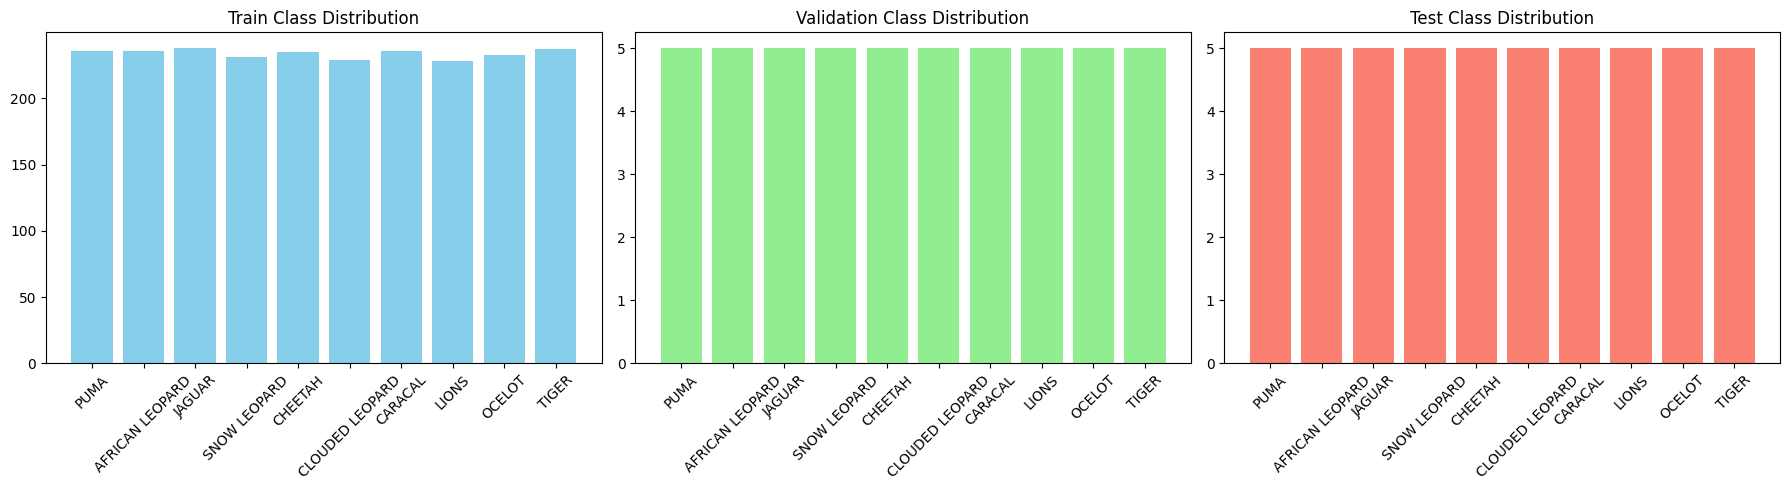


Image size statistics (first 200 train images):
Average width : 224.0
Average height: 224.0
Min width / Max width   : 224 / 224
Min height / Max height : 224 / 224


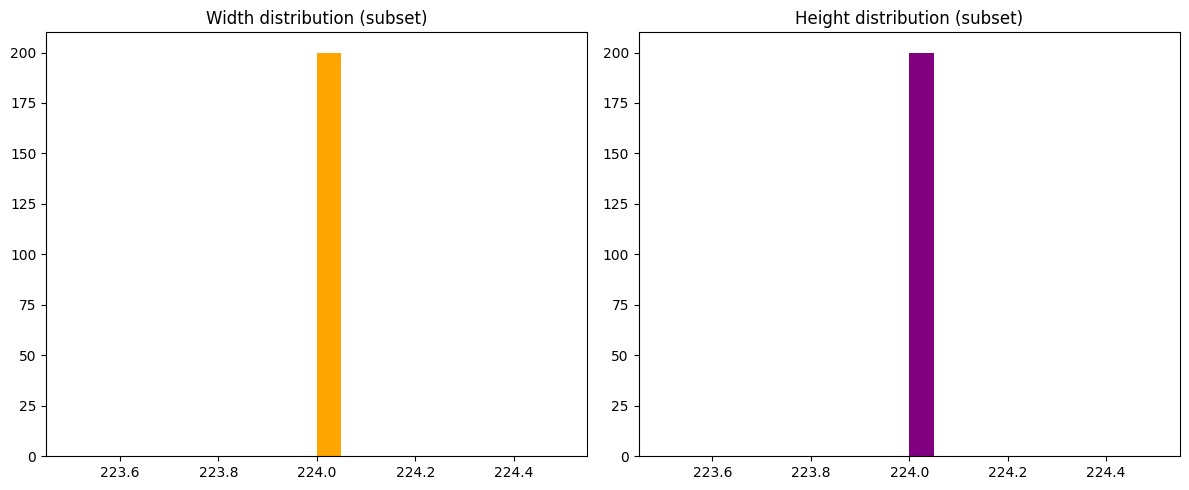


Showing sample images from the TRAIN set:


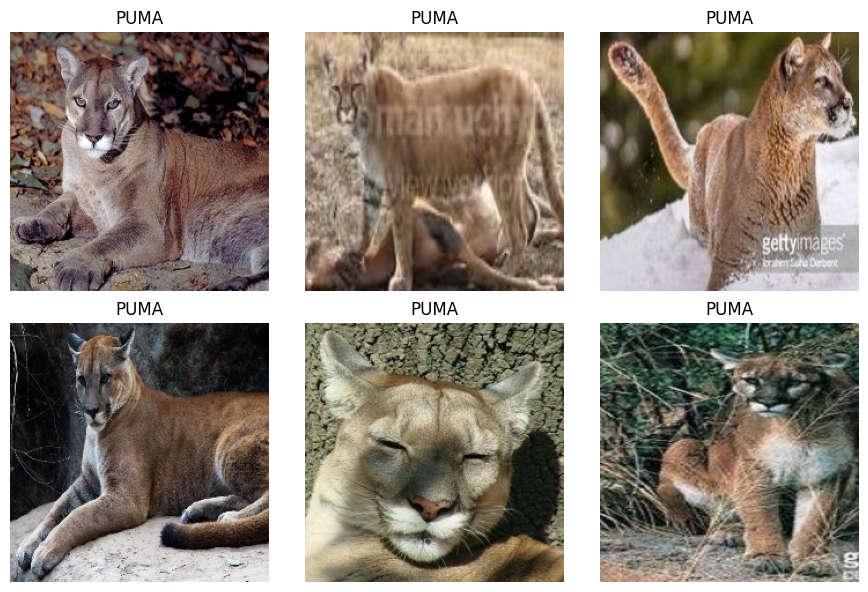

In [24]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import matplotlib.pyplot as plt
from collections import Counter


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


# 1. Dataset definition

class BigCatDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

        # ניפוי של קבצי .DS_Store
        classes = [
            os.path.join(root_dir, c)
            for c in os.listdir(root_dir)
            if c != ".DS_Store"
        ]

        # רשימת כל התמונות
        self.data = [
            os.path.join(c, d)
            for c in classes
            for d in os.listdir(c)
            if d != ".DS_Store"
        ]

        # שמות ה-classes עצמם
        self.classes = [os.path.basename(c) for c in classes]
        self.classes.sort()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]

        class_name = os.path.basename(os.path.dirname(img_path))
        label = self.classes.index(class_name)

        # convert to RGB למקרה שיש ערוץ אלפא
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label

    def get_class(self, i):
        return self.classes[i]


data_root = "/content/hw1_data/big_cats"

train_root = os.path.join(data_root, "train")
val_root   = os.path.join(data_root, "valid")
test_root  = os.path.join(data_root, "test")


train = BigCatDataset(train_root)
val   = BigCatDataset(val_root)
test  = BigCatDataset(test_root)



# 3. מידע בסיסי על הדאטהסט
print("Number of training images:", len(train))
print("Number of validation images:", len(val))
print("Number of test images:", len(test))
print("\nClasses:", train.classes)
print("Number of classes:", len(train.classes))


# 4. התפלגות מחלקות (class distribution)
def get_class_distribution(dataset):
    labels = []
    for _, label in dataset:   # לא פותחים את כל התמונות לזמן ארוך
        labels.append(label)
    return Counter(labels)


train_dist_ids = get_class_distribution(train)
val_dist_ids   = get_class_distribution(val)
test_dist_ids  = get_class_distribution(test)

train_dist = {train.get_class(k): v for k, v in train_dist_ids.items()}
val_dist   = {val.get_class(k): v for k, v in val_dist_ids.items()}
test_dist  = {test.get_class(k): v for k, v in test_dist_ids.items()}




print("\nTrain distribution:", train_dist)
print("Validation distribution:", val_dist)
print("Test distribution:", test_dist)


# 5. גרפים של התפלגות המחלקות
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(train_dist.keys(), train_dist.values(), color='skyblue')
ax[0].set_title("Train Class Distribution")
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(val_dist.keys(), val_dist.values(), color='lightgreen')
ax[1].set_title("Validation Class Distribution")
ax[1].tick_params(axis='x', rotation=45)

ax[2].bar(test_dist.keys(), test_dist.values(), color='salmon')
ax[2].set_title("Test Class Distribution")
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# 6. סטטיסטיקות על גודל התמונות (על תת-קבוצה קטנה כדי לא להפיל את הקרנל)
def get_sizes(dataset, max_images=200):
    widths, heights = [], []
    for i, path in enumerate(dataset.data):
        if i >= max_images:
            break
        # כדי לא לדלוף זיכרון – נסגור כל תמונה מיד אחרי הקריאה
        with Image.open(path) as img:
            w, h = img.size
        widths.append(w)
        heights.append(h)
    return widths, heights

train_w, train_h = get_sizes(train, max_images=200)

print("\nImage size statistics (first 200 train images):")
print("Average width :", float(np.mean(train_w)))
print("Average height:", float(np.mean(train_h)))
print("Min width / Max width   :", int(np.min(train_w)), "/", int(np.max(train_w)))
print("Min height / Max height :", int(np.min(train_h)), "/", int(np.max(train_h)))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_w, bins=20, color='orange')
plt.title("Width distribution (subset)")
plt.subplot(1, 2, 2)
plt.hist(train_h, bins=20, color='purple')
plt.title("Height distribution (subset)")
plt.tight_layout()
plt.show()


# 7. הצגת כמה דוגמאות (מעט תמונות כדי לא להפיל את הקרנל)
def show_samples(dataset, n=6):
    n = min(n, len(dataset))
    rows = 2
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()  # CHW -> HWC

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(dataset.get_class(label))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nShowing sample images from the TRAIN set:")
show_samples(train, n=6)

Using device: cuda
Epoch [1/35] Train Loss: 1.8609, Train Acc: 30.01% | Val Loss: 1.5711, Val Acc: 40.00%
Epoch [2/35] Train Loss: 1.5673, Train Acc: 39.68% | Val Loss: 2.5609, Val Acc: 22.00%
Epoch [3/35] Train Loss: 1.4180, Train Acc: 45.40% | Val Loss: 1.5133, Val Acc: 42.00%
Epoch [4/35] Train Loss: 1.3083, Train Acc: 49.34% | Val Loss: 1.8765, Val Acc: 44.00%
Epoch [5/35] Train Loss: 1.1974, Train Acc: 54.81% | Val Loss: 1.2147, Val Acc: 50.00%
Epoch [6/35] Train Loss: 1.1261, Train Acc: 58.14% | Val Loss: 1.0162, Val Acc: 62.00%
Epoch [7/35] Train Loss: 1.0911, Train Acc: 60.07% | Val Loss: 2.8223, Val Acc: 30.00%
Epoch [8/35] Train Loss: 1.0458, Train Acc: 62.98% | Val Loss: 1.0230, Val Acc: 56.00%
Epoch [9/35] Train Loss: 1.0231, Train Acc: 61.95% | Val Loss: 1.2425, Val Acc: 46.00%
Epoch [10/35] Train Loss: 0.9755, Train Acc: 62.98% | Val Loss: 1.1336, Val Acc: 58.00%
Epoch [11/35] Train Loss: 0.8916, Train Acc: 67.29% | Val Loss: 0.7708, Val Acc: 70.00%
Epoch [12/35] Train Lo

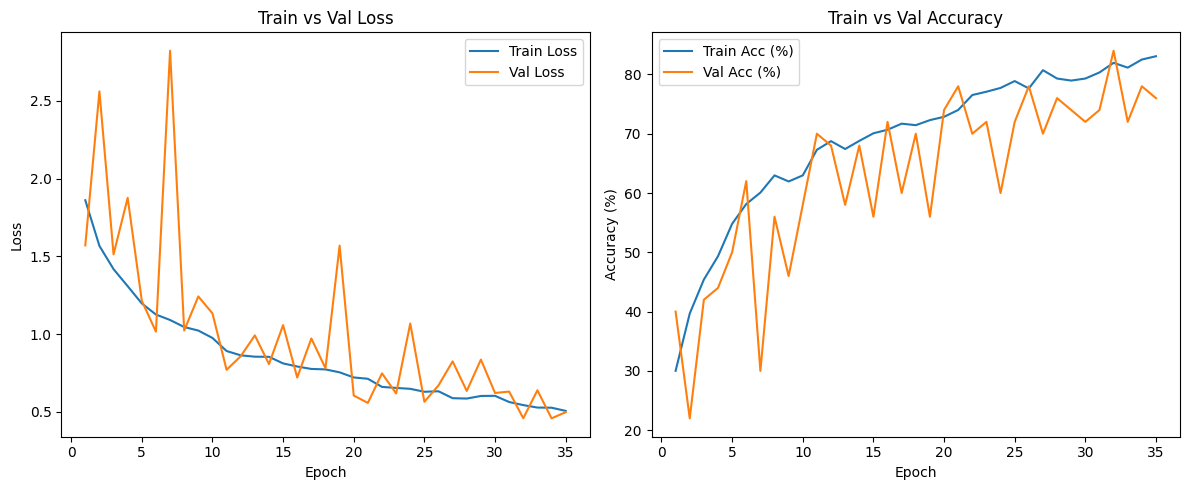

Test accuracy: 92.00%
Saved HW1_Q4_325468510_213690928.py
Saved HW1_Q4_325468510_213690928.pkl


In [27]:
# Stage 2+3: Deeper CNN, Plots, #params, Test accuracy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Transforms ----------
# TRAIN – (RandomResizedCrop, Flip, Rotation וכו')
train.transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# VAL/TEST – בלי אוגמנטציה, רק resize + נורמליזציה
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val.transform  = eval_transform
test.transform = eval_transform

# ---------- DataLoaders ----------
batch_size = 64

train_loader = DataLoader(train, batch_size=batch_size,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val,   batch_size=batch_size,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test,  batch_size=batch_size,
                          shuffle=False, num_workers=2)

# ---------- Deep CNN Model (no pretrained) ----------
class BigCatCNN(nn.Module):

    def __init__(self, num_classes=10):
        super(BigCatCNN, self).__init__()
        def conv_block(in_ch, out_ch, p_drop=0.0):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(p_drop)
            )

        self.features = nn.Sequential(
            conv_block(3,    32,  p_drop=0.0),   # 224 -> 112
            conv_block(32,   64,  p_drop=0.0),   # 112 -> 56
            conv_block(64,  128,  p_drop=0.05),  # 56  -> 28
            conv_block(128, 256,  p_drop=0.10),  # 28  -> 14
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # 256 x 1 x 1

        self.classifier = nn.Sequential(
            nn.Flatten(),            # 256
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# ---------- Training function (scheduler + best model) ----------
def train_model(model, train_loader, val_loader,
                epochs=35, lr=1e-3, seed=42):

    set_seed(seed)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=lr, weight_decay=1e-4)


    scheduler = optim.lr_scheduler.StepLR(optimizer,
                                          step_size=10, gamma=0.5)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc  = correct / total

        # ----- VALIDATION -----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc  = val_correct / val_total

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        # עדכון scheduler
        scheduler.step()

        # שמירת המודל הכי טוב לפי Val Accuracy
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Train Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_acc*100:.2f}%")

    # טוענים את הגרסה הכי טובה לפני בדיקת TEST
    model.load_state_dict(best_wts)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
    }
    return model, history

# ---------- אימון המודל + ספירת פרמטרים ----------
num_classes = len(train.classes)
model = BigCatCNN(num_classes=num_classes)

epochs = 35
lr = 1e-3

model, history = train_model(model, train_loader, val_loader,
                             epochs=epochs, lr=lr, seed=42)

total_params = sum(p.numel() for p in model.parameters())
print("Total number of parameters in the model:", total_params)

# ---------- גרפים של Loss ו-Accuracy ----------
epochs_range = range(1, len(history["train_losses"]) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_losses"], label="Train Loss")
plt.plot(epochs_range, history["val_losses"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, [a*100 for a in history["train_accs"]], label="Train Acc (%)")
plt.plot(epochs_range, [a*100 for a in history["val_accs"]],   label="Val Acc (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Val Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# ---------- Test accuracy (Stage 3) ----------
def evaluate_accuracy(model, data_loader):
    model = model.to(device)
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

test_acc = evaluate_accuracy(model, test_loader)
print(f"Test accuracy: {test_acc*100:.2f}%")

# --- Save model class to BigCatCNN.py ---
model_code = """
import torch
import torch.nn as nn

class BigCatCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BigCatCNN, self).__init__()

        def conv_block(in_ch, out_ch, p_drop=0.0):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(p_drop)
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128, p_drop=0.05),
            conv_block(128, 256, p_drop=0.10),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x
"""

with open("HW1_Q4_325468510_213690928.py", "w") as f:
    f.write(model_code)

print("Saved HW1_Q4_325468510_213690928.py")

# --- Save model weights to .pkl ---
torch.save(model.state_dict(), "HW1_Q4_325468510_213690928.pkl")
print("Saved HW1_Q4_325468510_213690928.pkl")


## II. Analyzing a Pre-trained CNN (Filters) (10pt)

In this part, you are going to analyze a (large) pre-trained model. Pre-trained models are quite popular these days, as big companies can train really large models on large datasets (something that personal users can't do as they lack the sufficient hardware). These pre-trained models can be used to fine-tune on other/small datasets or used as components in other tasks (like using a pre-trained classifier for object detection).

All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

You can use the following transform to normalize:

`normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`
<a href="https://pytorch.org/vision/stable/models.html">Read more here</a>


1. Load a pre-trained VGG16 with PyTorch using `torchvision.models.vgg16(pretrained=True, progress=True, **kwargs)` (<a href="https://pytorch.org/vision/stable/models.html#classification">read more here</a>). Don't forget to use the model in evaluation mode (`model.eval()`).

2. Load the images in the `hw1_data/birds` folder and display them.

3. Pre-process the images to fit VGG16's architecture. What steps did you take?

4. Feed the images (forward pass) to the model. What are the outputs?

5. Choose an image of a dog in the `hw1_data/dogs` folder, display it and feed it to network. What are the outputs?

6. For the first 3 filters in the first layer of VGG16, plot their response (their output) for the image from section 5. Explain what do you see.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.6MB/s]


Loaded VGG16 pre-trained model.
Number of bird images: 2


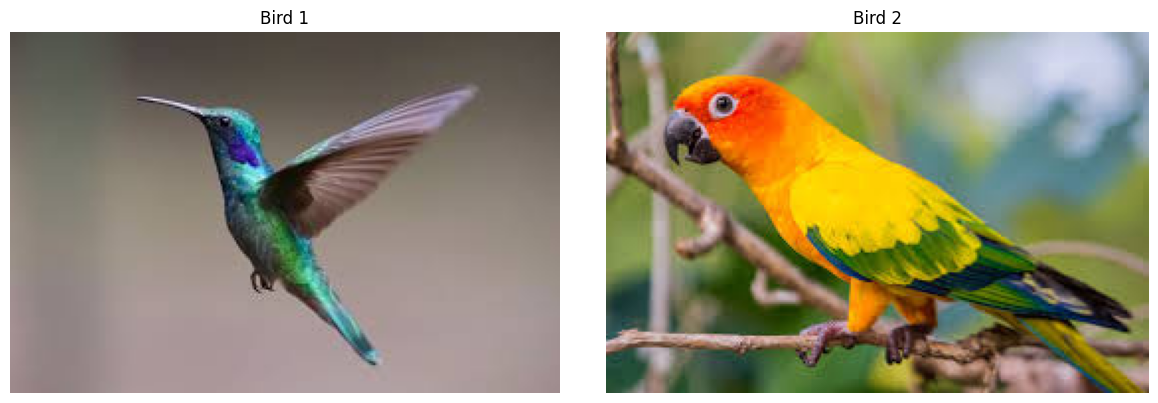

Birds batch shape: torch.Size([2, 3, 224, 224])
VGG16 outputs for birds – shape: torch.Size([2, 1000])
First bird – max probability: 0.6281450390815735 at class index: 94
Number of dog images: 10


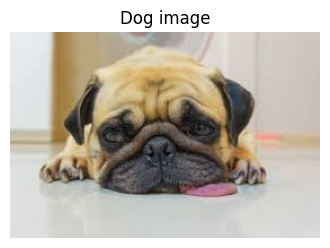

Dog tensor shape: torch.Size([1, 3, 224, 224])
Dog output shape: torch.Size([1, 1000])
Dog image – max probability: 0.9614222049713135 at class index: 254
Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
First conv output shape: torch.Size([1, 64, 224, 224])


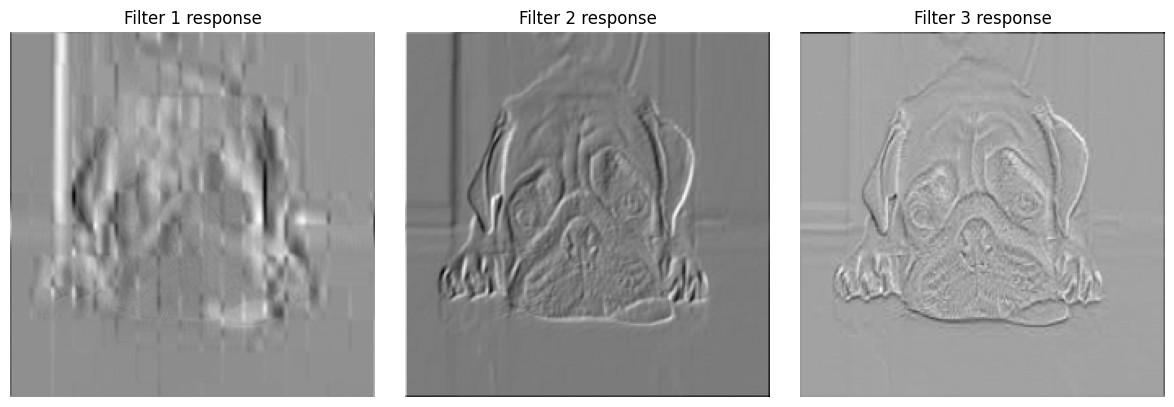

In [28]:
import os
import glob
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 0. Normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# טרנספורם מלא לתמונות קלט ל-VGG16
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # להתאים ל-224x224
    transforms.ToTensor(),          # [0,1]
    normalize                       # נרמול לפי ההנחיות
])

# 1. טעינת מודל VGG16 פרה-טריינד – לפי השורה במטלה
vgg16 = torchvision.models.vgg16(pretrained=True, progress=True)
vgg16.eval()

print("Loaded VGG16 pre-trained model.")


data_root = "/content/hw1_data"
birds_dir = os.path.join(data_root, "birds")

bird_paths = sorted(glob.glob(os.path.join(birds_dir, "*")))
print("Number of bird images:", len(bird_paths))

# נציג כמה תמונות ראשונות
num_to_show = len(bird_paths)

if num_to_show > 0:
    fig, axes = plt.subplots(1, num_to_show, figsize=(12, 4))
    if num_to_show == 1:
        axes = [axes]  # כדי שיהיה בר-איטרציה
    for i in range(num_to_show):
        img = Image.open(bird_paths[i]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"Bird {i+1}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No bird images found – check birds_dir path:", birds_dir)

#Section 3 — Pre-processing explanation (ANSWER)
#To pre-process the images for VGG16, I performed the following steps:
#Resizing: Each image was resized to 224×224, which is the required input size for VGG16.
#Converting to Tensor:The images were converted from PIL to PyTorch tensors using transforms.
#ToTensor(), which normalizes pixel values to the range [0,1][0,1].
#Normalizing:The images were normalized using VGG16’s ImageNet mean and std:
#mean = [0.485,0.456,0.406]std = [0.229,0.224,0.225]
#These steps ensure that the images match the expected distribution of VGG16’s pre-training data.

# נמיר את כל התמונות של הציפורים לטנזורים מנורמלים
bird_tensors = []

for p in bird_paths:
    img = Image.open(p).convert("RGB")
    img_t = preprocess(img)       # Resize -> ToTensor -> Normalize
    bird_tensors.append(img_t)

# ניצור batch אחד גדול
if len(bird_tensors) > 0:
    birds_batch = torch.stack(bird_tensors)  # shape: [N, 3, 224, 224]
    print("Birds batch shape:", birds_batch.shape)
else:
    birds_batch = None


if birds_batch is not None:
    with torch.no_grad():
        outputs_birds = vgg16(birds_batch)   # shape: [N, 1000]

    print("VGG16 outputs for birds – shape:", outputs_birds.shape)

    probs_first = torch.softmax(outputs_birds[0], dim=0)
    top_prob, top_idx = torch.max(probs_first, dim=0)
    print("First bird – max probability:", float(top_prob),
          "at class index:", int(top_idx))
#section 4: Answer:
#The output of the model for each image is a vector of length 1000.
#This vector contains VGG16’s predicted class scores for the 1000 ImageNet categories.
#For bird images: the output shape is [N, 1000]
#For a dog image: the output shape is [1, 1000]
#After applying softmax, the vector becomes a probability distribution,
#and the highest value corresponds to the predicted ImageNet class.

dogs_dir = os.path.join(data_root, "dogs")
dog_paths = sorted(glob.glob(os.path.join(dogs_dir, "*")))
print("Number of dog images:", len(dog_paths))

dog_img_path = dog_paths[0]
dog_img = Image.open(dog_img_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(dog_img)
plt.title("Dog image")
plt.axis("off")
plt.show()

# Pre-process – אותו preprocess כמו לציפורים
dog_tensor = preprocess(dog_img).unsqueeze(0)  # batch size 1, shape [1,3,224,224]

print("Dog tensor shape:", dog_tensor.shape)

with torch.no_grad():
    dog_output = vgg16(dog_tensor)  # shape [1, 1000]

print("Dog output shape:", dog_output.shape)

dog_probs = torch.softmax(dog_output[0], dim=0)
dog_top_prob, dog_top_idx = torch.max(dog_probs, dim=0)
print("Dog image – max probability:", float(dog_top_prob),
      "at class index:", int(dog_top_idx))


# השכבה הראשונה של VGG16 – conv layer
first_conv = vgg16.features[0]   # זה Conv2d הראשון

print(first_conv)

with torch.no_grad():
    conv_output = first_conv(dog_tensor)   # shape: [1, 64, H, W]

print("First conv output shape:", conv_output.shape)

# נבחר את 3 ה-channels הראשונים
first_three_maps = conv_output[0, :3, :, :].detach().cpu().numpy()

# נשרטט אותם
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    axes[i].imshow(first_three_maps[i], cmap="gray")
    axes[i].set_title(f"Filter {i+1} response")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

#section 6: Answer:
#The first convolutional layer filters extract very low-level visual features.
#The responses we plotted show:
#Edge detection – strong activation on edges of the dog’s face, ears, and wrinkles.
#Texture detection – filters highlight fine textures such as fur and background gradients.
#Basic gradients & contours – because this is the first layer,
#the filters capture primitive features (not shapes or objects).
#These early features are later combined in deeper layers to detect complex
#patterns like shapes, parts, and full objects.